In [1]:
!pip install bertopic sentence-transformers umap-learn hdbscan -q

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.5 MB/s eta 0:00:00


In [2]:
from google.colab import files
uploaded = files.upload()  # upload report_a.csv when prompted

df = pd.read_csv('report_a.csv', usecols=range(19), encoding='latin1')
df['CREATEDDATE'] = pd.to_datetime(df['CREATEDDATE'], errors='coerce')
print(df.shape)
df.head(2)

Saving Dankoff PRR(Report A_PatrolOfficer_SRO).csv to Dankoff PRR(Report A_PatrolOfficer_SRO).csv
(999, 19)


,CREATEDDATE,COMPLAINTNUMBER,Allegations,REPORTINGAGENCY,COMPLAINTPARTICIPANTNUMBER,OFFICERRANK,TITLE,GENDER,RACE,CERTIFICATIONSTATUS,NARRATIVE,UPDATEDNARRATIVE,Complaint Type (Complaint),Actions Already Taken (Complaint),LEA Disposition (Allegations),POSTC Disposition (Allegations),STATUS,Discipline,Updated Discipline
0,2025-11-26,12943.0,0,Bridgewater State University,P-00013086,NaN,Patrol Officer,NaN,NaN,Certified,"On October 14, 2025, at Bridgewater State Univ...",NaN,Public Complaint,0,0,0,No Action - Duplicate,NaN,NaN
1,2023-11-27,6403.0,"A-00021492,A-00021488,A-00021490,A-00021495,A-...",Walpole Police Department,P-00012309,Sergeant,Sergeant,NaN,NaN,Certified,I was pulled over for no reason buy a nice fem...,NaN,Public Complaint,I called the Walpole police department to get ...,Exonerated,Accept LEA Disposition,No Action - No investigation recommended,NaN,NaN


In [3]:
narrative = df['NARRATIVE'].fillna('') + ' ' + df['UPDATEDNARRATIVE'].fillna('')

youth_kw  = r'minor|juvenile|student|child|teen|youth|school|kid|underage'
force_kw  = r'arrest|use of force|taser|handcuff|choke|push|slam|restrain|detained|weapon|baton|pepper spray'
racial_kw = r'racist|racial|discrimination|bias|Black|Hispanic|Latino|minority'

df['youth_flag'] = narrative.str.contains(youth_kw, case=False, regex=True)
df['force_flag'] = narrative.str.contains(force_kw, case=False, regex=True)
df['racial_flag'] = narrative.str.contains(racial_kw, case=False, regex=True)
df['youth_force'] = df['youth_flag'] & df['force_flag']

print(df[['youth_flag','force_flag','youth_force','racial_flag']].sum())

youth_flag     354
force_flag     189
youth_force    185
racial_flag    102
dtype: int64


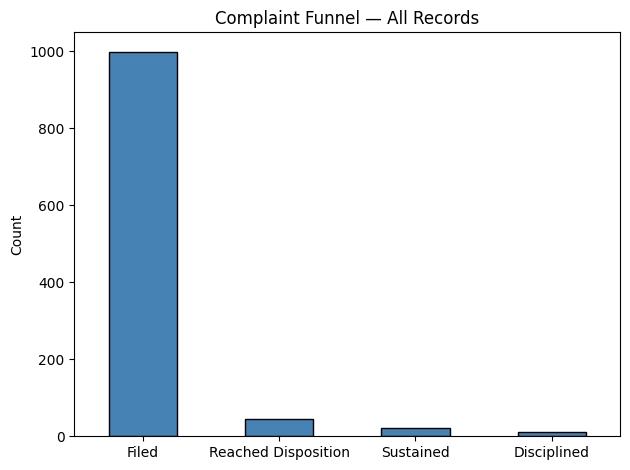

In [4]:
disp = df['LEA Disposition (Allegations)']
total        = len(df)
has_disp     = (disp != '0') & disp.notna()
sustained    = disp.str.contains('Sustained', na=False)
disciplined  = df['Discipline '].notna() & ~df['Discipline '].isin(['No Discipline Imposed','Not Applicable','0'])

stages = {
    'Filed': total,
    'Reached Disposition': has_disp.sum(),
    'Sustained':  sustained.sum(),
    'Disciplined': disciplined.sum()
}

pd.Series(stages).plot(kind='bar', color='steelblue', edgecolor='k')
plt.title('Complaint Funnel — All Records')
plt.ylabel('Count'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

In [5]:
def sustain_rate(mask, label):
    sub = df[mask]
    d = sub['LEA Disposition (Allegations)']
    reached = (d != '0') & d.notna()
    sustained = d.str.contains('Sustained', na=False)
    return {'Group': label, 'Complaints': len(sub),
            'Reached Disposition': reached.sum(),
            'Sustained': sustained.sum(),
            'Sustain Rate': f"{sustained.sum()/reached.sum():.1%}" if reached.sum() else 'N/A'}

rows = [
    sustain_rate(df['youth_flag'], 'Youth-related'),
    sustain_rate(~df['youth_flag'], 'Non-youth'),
    sustain_rate(df['youth_force'], 'Youth + Force'),
]
pd.DataFrame(rows)

,Group,Complaints,Reached Disposition,Sustained,Sustain Rate
0,Youth-related,354,44,21,47.7%
1,Non-youth,645,0,0,N/A
2,Youth + Force,185,21,5,23.8%


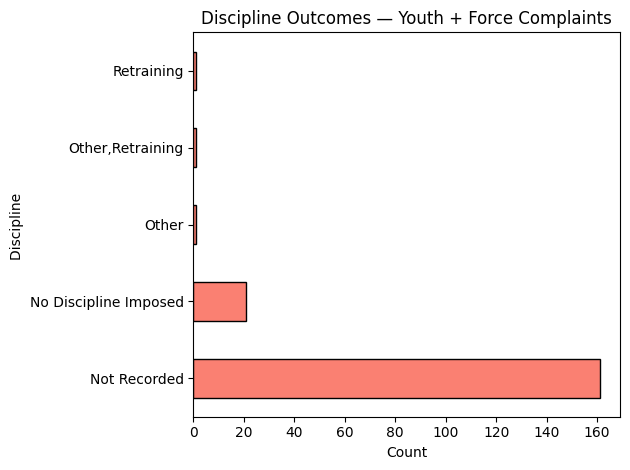

In [6]:
disc = df[df['youth_force']]['Discipline '].fillna('Not Recorded')
disc.value_counts().plot(kind='barh', color='salmon', edgecolor='k')
plt.title('Discipline Outcomes — Youth + Force Complaints')
plt.xlabel('Count'); plt.tight_layout(); plt.show()

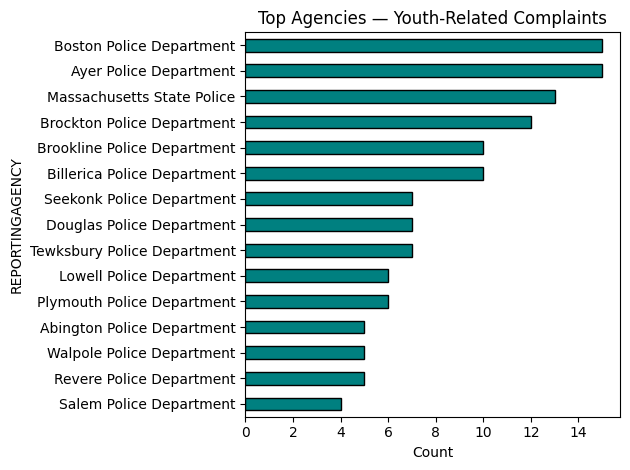

In [7]:
top_agencies = (df[df['youth_flag']]
                .groupby('REPORTINGAGENCY')
                .size()
                .sort_values(ascending=False)
                .head(15))

top_agencies.plot(kind='barh', color='teal', edgecolor='k')
plt.title('Top Agencies — Youth-Related Complaints')
plt.xlabel('Count'); plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

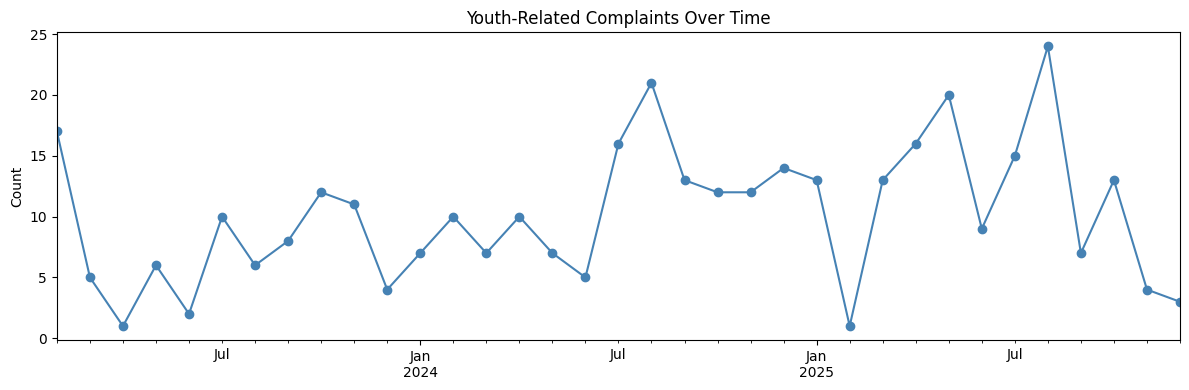

In [8]:
monthly = (df[df['youth_flag']]
           .set_index('CREATEDDATE')
           .resample('ME')
           .size())

monthly.plot(figsize=(12,4), marker='o', color='steelblue')
plt.title('Youth-Related Complaints Over Time')
plt.ylabel('Count'); plt.xlabel(''); plt.tight_layout(); plt.show()

In [9]:
from bertopic import BERTopic

# Use youth-flagged narratives only
docs = narrative[df['youth_flag']].dropna().tolist()
docs = [d for d in docs if len(d.strip()) > 50]  # drop near-empty

topic_model = BERTopic(language='english', calculate_probabilities=False,
                       min_topic_size=5, verbose=True)
topics, _ = topic_model.fit_transform(docs)

topic_model.get_topic_info().head(15)

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.
2026-03-10 14:29:33,868 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

2026-03-10 14:30:22,328 - BERTopic - Embedding - Completed ✓
2026-03-10 14:30:22,331 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-10 14:30:33,516 - BERTopic - Dimensionality - Completed ✓
2026-03-10 14:30:33,518 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-10 14:30:33,557 - BERTopic - Cluster - Completed ✓
2026-03-10 14:30:33,568 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-10 14:30:33,815 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,62,-1_the_and_to_of,"[the, and, to, of, my, in, was, redacted, me, ...","[On 4/30/21 and the wknd of, (case number is 2..."
1,0,37,0_of_and_the_to,"[of, and, the, to, that, in, this, for, with, ...","[October 8, 15, 19, the Worcester police emplo..."
2,1,32,1_the_was_to_and,"[the, was, to, and, he, dog, my, that, in, of]",[I called 911 around 7pm to report a crime in ...
3,2,30,2_my_the_to_and,"[my, the, to, and, daughter, in, was, of, her,...",[on August 13 around 7 AM while I was at the g...
4,3,29,3_redacted_to_and_my,"[redacted, to, and, my, the, of, me, police, w...","[The Family Court had been giving ""non legally..."
5,4,28,4_complainant_daughter_the_to,"[complainant, daughter, the, to, her, was, and...",[This complaint is being opened from a phone c...
6,5,22,5_the_school_dcf_to,"[the, school, dcf, to, and, injuries, of, in, ...","[On April 26, 2022, there was an incident invo..."
7,6,21,6_and_my_me_to,"[and, my, me, to, he, was, the, is, officer, not]",[When I realized that Officer Hale was activel...
8,7,14,7_redacted_the_that_to,"[redacted, the, that, to, stated, her, he, exp...","[ [REDACTED] alleged that on Saturday, 3/23/24..."
9,8,13,8_the_minor_of_was,"[the, minor, of, was, not, and, to, moffett, r...",[Below is a copy of the complaint filed with t...


In [10]:
# Top words per topic (text summary — reliable in Colab)
for topic_id in topic_model.get_topic_info()['Topic'].tolist()[1:11]:  # skip -1 outlier
    words = [w for w, _ in topic_model.get_topic(topic_id)]
    print(f"Topic {topic_id}: {', '.join(words[:8])}")

Topic 0: of, and, the, to, that, in, this, for
Topic 1: the, was, to, and, he, dog, my, that
Topic 2: my, the, to, and, daughter, in, was, of
Topic 3: redacted, to, and, my, the, of, me, police
Topic 4: complainant, daughter, the, to, her, was, and, said
Topic 5: the, school, dcf, to, and, injuries, of, in
Topic 6: and, my, me, to, he, was, the, is
Topic 7: redacted, the, that, to, stated, her, he, explained
Topic 8: the, minor, of, was, not, and, to, moffett
Topic 9: and, to, the, in, is, my, redacted, of


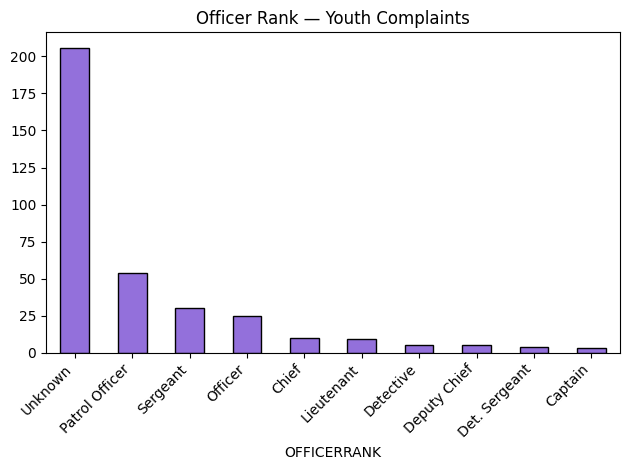

In [11]:
rank_youth = (df[df['youth_flag']]['OFFICERRANK']
              .fillna('Unknown')
              .value_counts()
              .head(10))

rank_youth.plot(kind='bar', color='mediumpurple', edgecolor='k')
plt.title('Officer Rank — Youth Complaints')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

In [13]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

# ── raw narrative ──────────────────────────────────────────────────────────────
narrative = df['NARRATIVE'].fillna('') + ' ' + df['UPDATEDNARRATIVE'].fillna('')
youth_mask = narrative.str.contains(
    r'minor|juvenile|student|child|teen|youth|school|kid|underage',
    case=False, regex=True)
youth_narratives = narrative[youth_mask].reset_index(drop=True)

# ── AGE extraction ─────────────────────────────────────────────────────────────
age_patterns = [
    r'\b(\d{1,2})[- ]year[s]?[- ]old\b',
    r'\bage[d]?\s*[:\-]?\s*(\d{1,2})\b',
    r'\b(\d{1,2})[- ]yo\b',
    r'\bjuvenile[,\s]+(\d{1,2})\b',
]

def extract_ages(text):
    ages = []
    for pat in age_patterns:
        for m in re.finditer(pat, text, re.IGNORECASE):
            a = int(m.group(1))
            if 1 <= a <= 17:
                ages.append(a)
    return ages

all_ages = []
for t in youth_narratives:
    all_ages.extend(extract_ages(t))

print(f"Age mentions found: {len(all_ages)}")
print(f"Distribution:\n{pd.Series(all_ages).value_counts().sort_index()}")

Age mentions found: 140
Distribution:
1      1
2      7
3     15
4     13
5      8
6      8
7     17
8      5
9      7
10     4
11     4
12     9
13    11
14     7
15    12
16     6
17     6
Name: count, dtype: int64


In [14]:
race_patterns = {
    'Black / African American': r'\b(Black|African[- ]American)\b',
    'White':                    r'\b(White|Caucasian)\b',
    'Hispanic / Latino':        r'\b(Hispanic|Latino|Latina|Latinx)\b',
    'Asian':                    r'\b(Asian|Chinese|Vietnamese|Korean|Indian)\b',
    'Native American':          r'\b(Native American|Indigenous|tribal)\b',
    'Middle Eastern':           r'\b(Middle Eastern|Arab|Muslim)\b',   # proxy
}

race_counts = {}
for label, pat in race_patterns.items():
    race_counts[label] = youth_narratives.str.contains(pat, case=False, regex=True).sum()

race_series = pd.Series(race_counts).sort_values(ascending=False)
print(race_series)

Black / African American    36
White                       17
Hispanic / Latino            4
Native American              2
Asian                        1
Middle Eastern               0
dtype: int64


In [15]:
gender_patterns = {
    'Male':   r'\b(boy|he|his|him|male|son|brother|grandson)\b',
    'Female': r'\b(girl|she|her|female|daughter|sister|granddaughter)\b',
}

gender_counts = {}
for label, pat in gender_patterns.items():
    gender_counts[label] = youth_narratives.str.contains(pat, case=False, regex=True).sum()

print(pd.Series(gender_counts))

Male      291
Female    251
dtype: int64


In [16]:
injury_patterns = {
    'Physical injury (general)': r'\b(injur|wound|hurt|pain|bruise|bleed|blood|lacerat)\w*\b',
    'Broken bone / fracture':    r'\b(fracture|broken bone|broke|break)\b',
    'Hospitalized':              r'\b(hospital|ER|emergency room|ambulance|EMS|medic)\b',
    'Psychological harm':        r'\b(trauma|PTSD|anxiety|fear|distress|mental health|scared|crying)\b',
    'Death':                     r'\b(death|died|killed|fatality|deceased)\b',
    'Taser / stun':              r'\b(taser|tased|stun gun|electroshock)\b',
    'Choke / restrain':          r'\b(choke|strangle|restrain|pin|hold down|arm behind)\b',
}

injury_counts = {}
for label, pat in injury_patterns.items():
    injury_counts[label] = youth_narratives.str.contains(pat, case=False, regex=True).sum()

injury_series = pd.Series(injury_counts).sort_values(ascending=False)
print(injury_series)

Psychological harm           147
Physical injury (general)     93
Hospitalized                  64
Death                         42
Broken bone / fracture        31
Choke / restrain               7
Taser / stun                   3
dtype: int64


In [18]:
sa_patterns = {
    'Sexual assault / rape':     r'\b(sexual assault|rape|raped|sexually assault)\w*\b',
    'Inappropriate touching':    r'\b(inappropriat\w* touch|grope|groped|fondle|fondl)\w*\b',
    'Sexual harassment':         r'\b(sexual harassment|sexually harass)\w*\b',
    'Exposure / indecency':      r'\b(expos\w*|indecen\w*|flashe[ds]?|genital)\b',
    'Solicitation / coercion':   r'\b(solicit|coerce|coercion|pressure[ds]? for sex|sex in exchange)\b',
    'Grooming':                  r'\b(groom\w*|manipulat\w*|exploit\w*)\b',
}

sa_counts = {}
sa_record_flags = pd.Series(False, index=youth_narr.index)

for label, pat in sa_patterns.items():
    mask = youth_narr.str.contains(pat, case=False, regex=True)
    sa_counts[label] = mask.sum()
    sa_record_flags = sa_record_flags | mask

sa_series = pd.Series(sa_counts).sort_values(ascending=False)
print(f"Total youth complaints with ANY sexual assault language: {sa_record_flags.sum()}")
print(f"\nBreakdown:\n{sa_series}")

Total youth complaints with ANY sexual assault language: 62

Breakdown:
Grooming                   32
Sexual assault / rape      27
Exposure / indecency        9
Solicitation / coercion     3
Sexual harassment           2
Inappropriate touching      1
dtype: int64


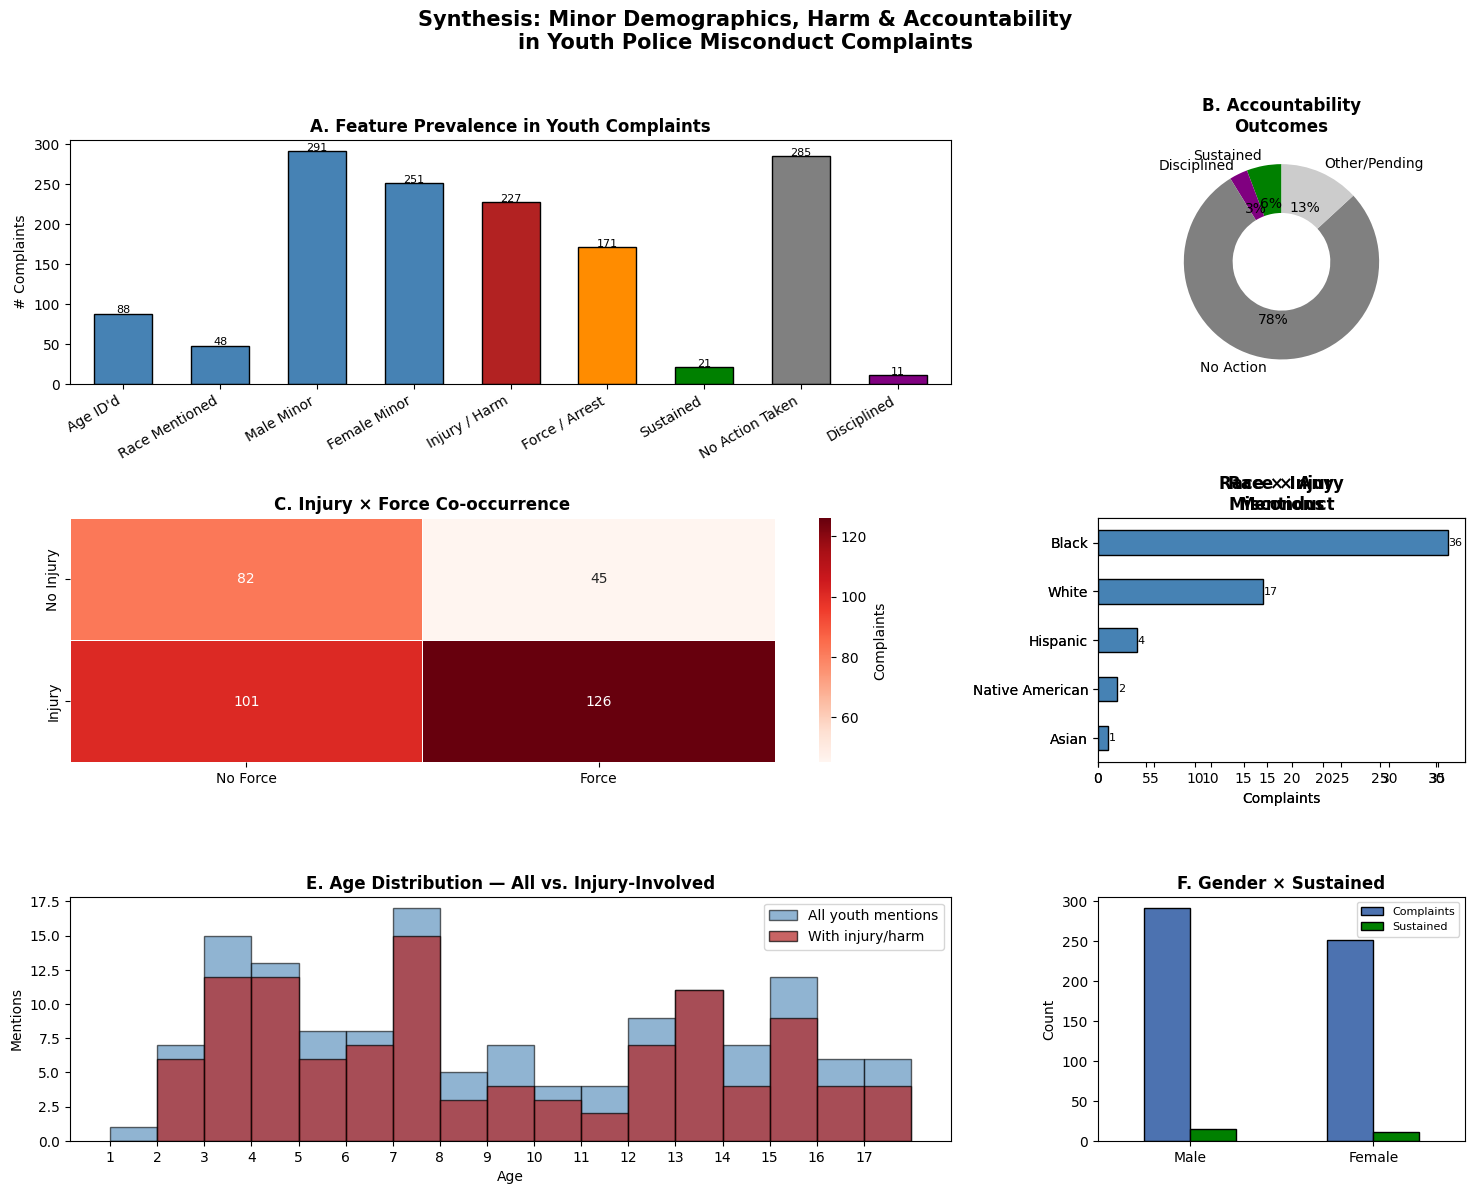

Saved: minor_misconduct_synthesis.png


In [26]:
# Build a per-complaint feature matrix for youth complaints only
youth_df = df[youth_mask].copy().reset_index(drop=True)
youth_narr = narrative[youth_mask].reset_index(drop=True)

youth_df['age_mentioned']   = youth_narr.apply(lambda t: len(extract_ages(t)) > 0)
youth_df['race_mentioned']  = youth_narr.str.contains(
    '|'.join(race_patterns.values()), case=False, regex=True)
youth_df['male_minor']      = youth_narr.str.contains(gender_patterns['Male'],   case=False, regex=True)
youth_df['female_minor']    = youth_narr.str.contains(gender_patterns['Female'], case=False, regex=True)
youth_df['any_injury']      = youth_narr.str.contains(
    '|'.join(injury_patterns.values()), case=False, regex=True)
youth_df['force_flag']      = youth_narr.str.contains(
    r'arrest|use of force|taser|handcuff|choke|restrain|detained|weapon|baton',
    case=False, regex=True)
youth_df['sustained']       = youth_df['LEA Disposition (Allegations)'].str.contains(
    'Sustained', na=False)
youth_df['no_action']       = youth_df['STATUS'].str.contains('No Action', na=False)
youth_df['disciplined']     = (
    youth_df['Discipline '].notna() &
    ~youth_df['Discipline '].isin(['No Discipline Imposed','Not Applicable','0',''])
)

features = ['age_mentioned','race_mentioned','male_minor','female_minor',
            'any_injury','force_flag','sustained','no_action','disciplined']

# ── Synthesis figure ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 13))
fig.suptitle('Synthesis: Minor Demographics, Harm & Accountability\nin Youth Police Misconduct Complaints',
             fontsize=15, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

# ── A. Prevalence bar ──────────────────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, :2])
prev = youth_df[features].sum().rename({
    'age_mentioned':'Age ID\'d','race_mentioned':'Race Mentioned',
    'male_minor':'Male Minor','female_minor':'Female Minor',
    'any_injury':'Injury / Harm','force_flag':'Force / Arrest',
    'sustained':'Sustained','no_action':'No Action Taken','disciplined':'Disciplined'
})
colors = ['steelblue']*4 + ['firebrick'] + ['darkorange'] + ['green','grey','purple']
prev.plot(kind='bar', ax=ax_a, color=colors, edgecolor='k', width=0.6)
ax_a.set_title('A. Feature Prevalence in Youth Complaints', fontweight='bold')
ax_a.set_ylabel('# Complaints')
ax_a.set_xticklabels(prev.index, rotation=30, ha='right')
for i, v in enumerate(prev):
    ax_a.text(i, v + 0.5, str(v), ha='center', fontsize=8)

# ── B. Accountability donut ────────────────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 2])
acc_vals = [youth_df['sustained'].sum(),
            youth_df['disciplined'].sum(),
            youth_df['no_action'].sum(),
            len(youth_df) - youth_df[['sustained','disciplined','no_action']].any(axis=1).sum()]
acc_labels = ['Sustained','Disciplined','No Action','Other/Pending']
acc_colors = ['green','purple','grey','#CCCCCC']
non_zero = [(v, l, c) for v, l, c in zip(acc_vals, acc_labels, acc_colors) if v > 0]
ax_b.pie([x[0] for x in non_zero],
         labels=[x[1] for x in non_zero],
         colors=[x[2] for x in non_zero],
         autopct='%1.0f%%', startangle=90,
         wedgeprops=dict(width=0.5))
ax_b.set_title('B. Accountability\nOutcomes', fontweight='bold')

# ── C. Injury × Force heatmap ─────────────────────────────────────────────────
ax_c = fig.add_subplot(gs[1, :2])
cross = pd.crosstab(youth_df['any_injury'], youth_df['force_flag'],
                    rownames=['Injury Mentioned'], colnames=['Force / Arrest'])
cross.index = ['No Injury', 'Injury']
cross.columns = ['No Force', 'Force']
sns.heatmap(cross, annot=True, fmt='d', cmap='Reds', ax=ax_c, linewidths=0.5,
            cbar_kws={'label': 'Complaints'})
ax_c.set_title('C. Injury × Force Co-occurrence', fontweight='bold')

# ── D. Race × Injury ──────────────────────────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 2])
race_injury = {}
for label, pat in race_patterns.items():
    race_mask_local = youth_narr.str.contains(pat, case=False, regex=True)
    injury_mask_local = youth_narr.str.contains(
        '|'.join(injury_patterns.values()), case=False, regex=True)
    race_injury[label.split('/')[0].strip()] = (race_mask_local & injury_mask_local).sum()

ri = pd.Series(race_injury).sort_values()[lambda s: s > 0]
ri.plot(kind='barh', ax=ax_d, color='darksalmon', edgecolor='k')
ax_d.set_title('Race × Injury\nMentions', fontweight='bold')
ax_d.set_xlabel('Complaints')

# ── E. Age histogram with injury overlay ──────────────────────────────────────
ax_e = fig.add_subplot(gs[2, :2])
injury_narr_mask = youth_narr.str.contains(
    '|'.join(injury_patterns.values()), case=False, regex=True)

ages_all    = []
ages_injury = []
for i, t in enumerate(youth_narr):
    a = extract_ages(t)
    ages_all.extend(a)
    if injury_narr_mask.iloc[i]:
        ages_injury.extend(a)

bins = range(1, 19)
ax_e.hist(ages_all,    bins=bins, alpha=0.6, color='steelblue', label='All youth mentions', edgecolor='k')
ax_e.hist(ages_injury, bins=bins, alpha=0.7, color='firebrick', label='With injury/harm',   edgecolor='k')
ax_e.set_title('E. Age Distribution — All vs. Injury-Involved', fontweight='bold')
ax_e.set_xlabel('Age'); ax_e.set_ylabel('Mentions')
ax_e.set_xticks(range(1, 18))
ax_e.legend()

# ── F. Gender × Sustained ─────────────────────────────────────────────────────
ax_f = fig.add_subplot(gs[2, 2])
gd = {
    'Male':   [youth_df['male_minor'].sum(),   (youth_df['male_minor']   & youth_df['sustained']).sum()],
    'Female': [youth_df['female_minor'].sum(),  (youth_df['female_minor'] & youth_df['sustained']).sum()],
}
gd_df = pd.DataFrame(gd, index=['Complaints','Sustained']).T
gd_df.plot(kind='bar', ax=ax_f, color=['#4C72B0','green'], edgecolor='k', width=0.5)
ax_f.set_title('F. Gender × Sustained', fontweight='bold')
ax_f.set_xticklabels(['Male','Female'], rotation=0)
ax_f.set_ylabel('Count')
ax_f.legend(fontsize=8)

ax_d = fig.add_subplot(gs[1, 2])

race_misconduct = {}
all_misconduct_pat = '|'.join(misconduct_categories.values())
for label, pat in race_patterns.items():
    race_mask_local = youth_narr.str.contains(pat, case=False, regex=True)
    misc_mask_local = youth_narr.str.contains(all_misconduct_pat, case=False, regex=True)
    race_misconduct[label.split('/')[0].strip()] = (race_mask_local & misc_mask_local).sum()

rm = pd.Series(race_misconduct).sort_values()
rm = rm[rm > 0]
rm.plot(kind='barh', ax=ax_d, color='steelblue', edgecolor='k')
ax_d.set_title('Race × Any\nMisconduct', fontweight='bold')
ax_d.set_xlabel('Complaints')
for i, v in enumerate(rm):
    ax_d.text(v + 0.1, i, str(v), va='center', fontsize=8)

plt.savefig('minor_misconduct_synthesis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: minor_misconduct_synthesis.png")

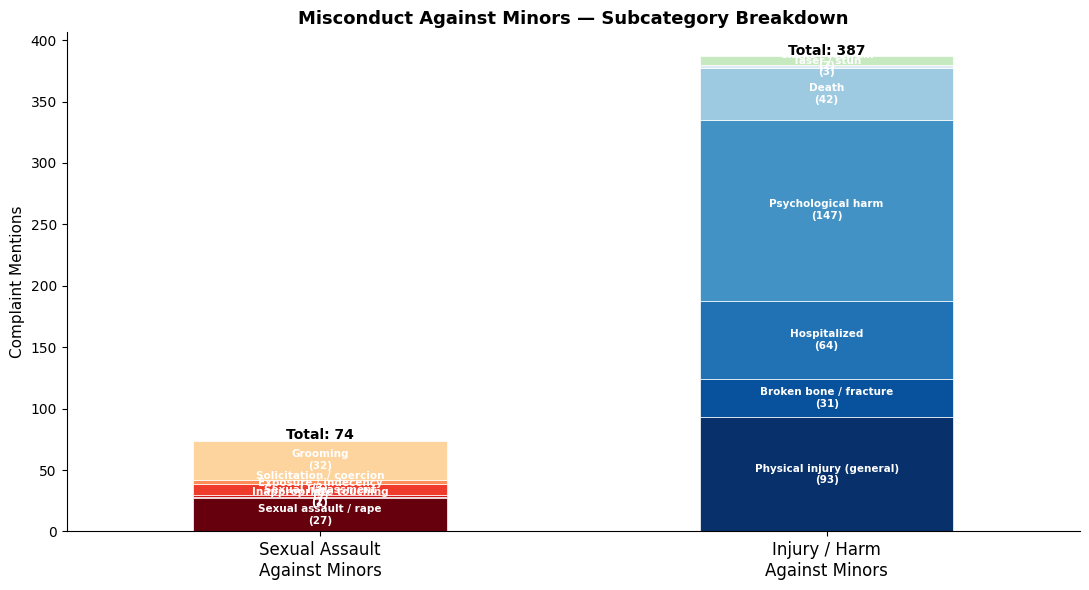

In [19]:
# ── Stacked bar: Misconduct type → subcategory breakdown ──────────────────────

sa_sub_labels = list(sa_patterns.keys())
injury_sub_labels = list(injury_patterns.keys())

# Count each subcategory for SA
sa_sub_counts = {}
for label, pat in sa_patterns.items():
    sa_sub_counts[label] = youth_narr.str.contains(pat, case=False, regex=True).sum()

# Count each subcategory for Injury
injury_sub_counts = {}
for label, pat in injury_patterns.items():
    injury_sub_counts[label] = youth_narr.str.contains(pat, case=False, regex=True).sum()

# Build dataframes — one row per main category, columns = subcategories
sa_df     = pd.DataFrame([sa_sub_counts],     index=['Sexual Assault'])
injury_df = pd.DataFrame([injury_sub_counts], index=['Injury / Harm'])

# Combine into one frame, filling missing cols with 0
combined = pd.concat([sa_df, injury_df], axis=0).fillna(0)

# ── Plot ───────────────────────────────────────────────────────────────────────
sa_colors     = ['#67000d','#a50f15','#cb181d','#ef3b2c','#fc8d59','#fdd49e']
injury_colors = ['#08306b','#08519c','#2171b5','#4292c6','#9ecae1','#deebf7','#c7e9c0']

fig, ax = plt.subplots(figsize=(11, 6))

bottom = np.zeros(2)
all_colors = sa_colors[:len(sa_sub_counts)] + injury_colors[:len(injury_sub_counts)]
all_labels = list(sa_sub_counts.keys()) + list(injury_sub_counts.keys())
all_values = list(sa_sub_counts.values()) + list(injury_sub_counts.values())

# Plot SA subcategories on bar 0, injury subcategories on bar 1
sa_bottom = 0
for i, (label, pat) in enumerate(sa_patterns.items()):
    val = sa_sub_counts[label]
    ax.bar(0, val, bottom=sa_bottom, color=sa_colors[i], edgecolor='white',
           linewidth=0.5, label=label, width=0.5)
    if val > 0:
        ax.text(0, sa_bottom + val/2, f'{label}\n({val})',
                ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')
    sa_bottom += val

inj_bottom = 0
for i, (label, pat) in enumerate(injury_patterns.items()):
    val = injury_sub_counts[label]
    ax.bar(1, val, bottom=inj_bottom, color=injury_colors[i], edgecolor='white',
           linewidth=0.5, label=label, width=0.5)
    if val > 2:
        ax.text(1, inj_bottom + val/2, f'{label}\n({val})',
                ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')
    inj_bottom += val

# Totals on top
ax.text(0, sa_bottom + 1,     f'Total: {int(sa_bottom)}',  ha='center', fontsize=10, fontweight='bold')
ax.text(1, inj_bottom + 1,    f'Total: {int(inj_bottom)}', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Sexual Assault\nAgainst Minors', 'Injury / Harm\nAgainst Minors'], fontsize=12)
ax.set_ylabel('Complaint Mentions', fontsize=11)
ax.set_title('Misconduct Against Minors — Subcategory Breakdown', fontsize=13, fontweight='bold')
ax.set_xlim(-0.5, 1.5)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('misconduct_stacked_subcategories.png', dpi=150, bbox_inches='tight')
plt.show()

                   0–5  6–10  11–13  14–15  16–17  Unknown / Unspecified
Sexual Assault       5     9      6      3      1                     38
Injury / Harm       21    20     13      6      5                    162
Excessive Force     20    11     13      6      3                    132
Racial Bias         11    10     11      2      0                     61
False Arrest         4     1      6      0      0                     24
Privacy Violation    6     3      0      3      0                     27
Intimidation        14    14     11      7      4                    135


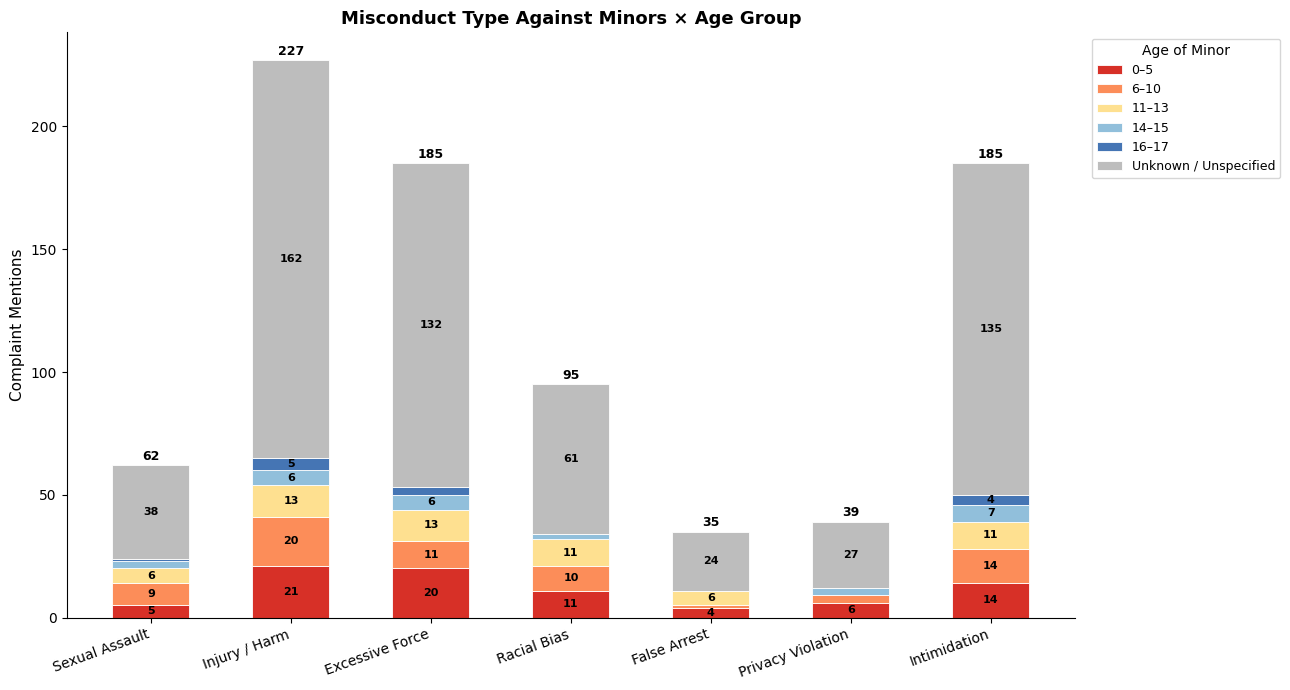

In [20]:
# ── Misconduct type × Age of minor (stacked bar) ──────────────────────────────

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Age buckets per complaint ──────────────────────────────────────────────────
def age_bucket(text):
    ages = extract_ages(text)  # reuse your existing function
    if not ages:
        return 'Unknown / Unspecified'
    a = min(ages)  # use youngest mentioned if multiple
    if a <= 5:   return '0–5'
    if a <= 10:  return '6–10'
    if a <= 13:  return '11–13'
    if a <= 15:  return '14–15'
    return '16–17'

age_order = ['0–5', '6–10', '11–13', '14–15', '16–17', 'Unknown / Unspecified']

# ── Misconduct categories (reuse existing pattern dicts) ──────────────────────
misconduct_categories = {
    'Sexual Assault': r'|'.join(sa_patterns.values()),
    'Injury / Harm':  r'|'.join(injury_patterns.values()),
    'Excessive Force': r'arrest|use of force|taser|handcuff|choke|push|slam|restrain|detained|weapon|baton|pepper spray',
    'Racial Bias':     r'racist|racial|discrimination|bias|Black|Hispanic|Latino|minority',
    'False Arrest':    r'false arrest|wrongful arrest|false charges|fabricated|framed|unlawful arrest',
    'Privacy Violation': r'privacy|confidential|personal information|SSN|social security|record leak',
    'Intimidation':    r'threat|intimidat|bully|harass',
}

# ── Build matrix: misconduct × age bucket ─────────────────────────────────────
matrix = pd.DataFrame(0, index=list(misconduct_categories.keys()), columns=age_order)

for i, text in enumerate(youth_narr):
    bucket = age_bucket(text)
    for mtype, pat in misconduct_categories.items():
        if re.search(pat, text, re.IGNORECASE):
            matrix.loc[mtype, bucket] += 1

print(matrix)

# ── Color palette per age bucket ──────────────────────────────────────────────
age_colors = {
    '0–5':                   '#d73027',
    '6–10':                  '#fc8d59',
    '11–13':                 '#fee090',
    '14–15':                 '#91bfdb',
    '16–17':                 '#4575b4',
    'Unknown / Unspecified': '#bdbdbd',
}

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7))

bottoms = np.zeros(len(matrix))

for age_bucket_label in age_order:
    vals = matrix[age_bucket_label].values.astype(float)
    bars = ax.bar(
        matrix.index, vals,
        bottom=bottoms,
        color=age_colors[age_bucket_label],
        edgecolor='white', linewidth=0.6,
        label=age_bucket_label,
        width=0.55
    )
    # label inside segment if tall enough
    for j, (v, b) in enumerate(zip(vals, bottoms)):
        if v >= 4:
            ax.text(j, b + v / 2, str(int(v)),
                    ha='center', va='center', fontsize=8,
                    color='black', fontweight='bold')
    bottoms += vals

# totals on top
for j, total in enumerate(bottoms):
    ax.text(j, total + 1, str(int(total)),
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Complaint Mentions', fontsize=11)
ax.set_title('Misconduct Type Against Minors × Age Group', fontsize=13, fontweight='bold')
ax.set_xticklabels(matrix.index, rotation=20, ha='right', fontsize=10)
ax.legend(title='Age of Minor', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('misconduct_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

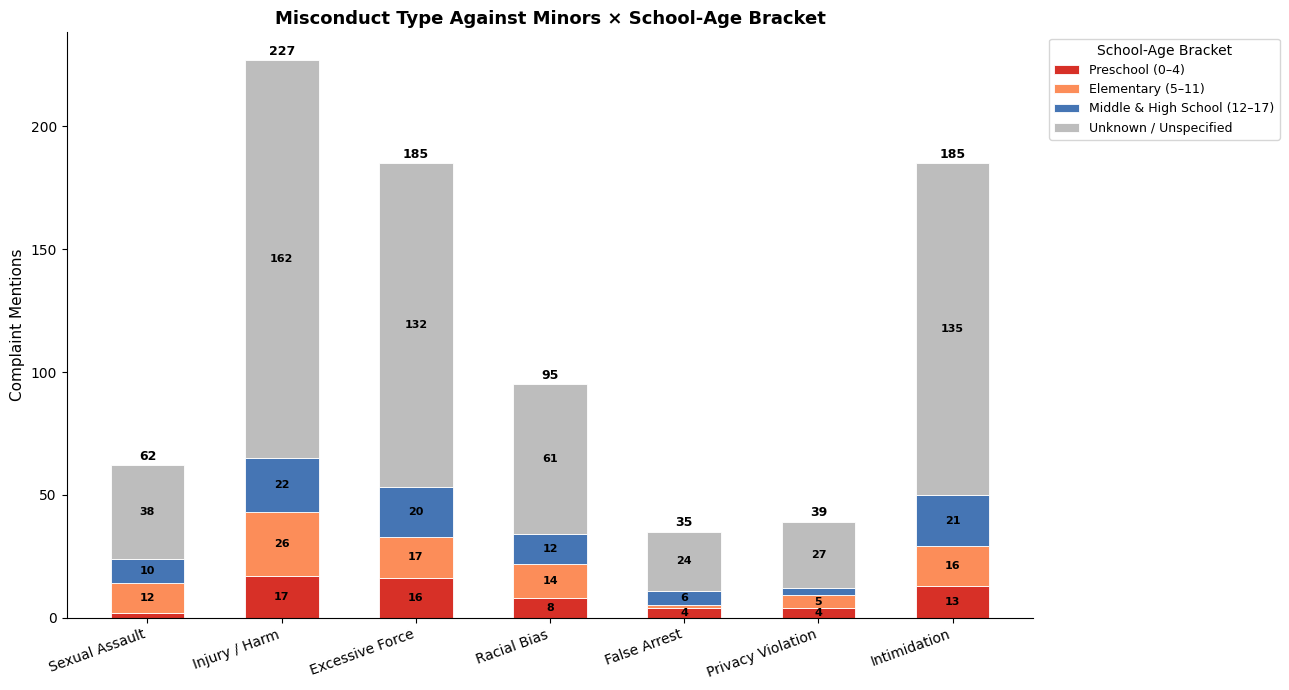

In [22]:
def school_age_bucket(text):
    ages = extract_ages(text)
    if not ages:
        return 'Unknown / Unspecified'
    a = min(ages)
    if a <= 4:   return 'Preschool (0–4)'
    if a <= 11:  return 'Elementary (5–11)'
    if a <= 17:  return 'Middle & High School (12–17)'
    return 'Unknown / Unspecified'

school_order = [
    'Preschool (0–4)',
    'Elementary (5–11)',
    'Middle & High School (12–17)',
    'Unknown / Unspecified'
]

school_colors = {
    'Preschool (0–4)':               '#d73027',
    'Elementary (5–11)':             '#fc8d59',
    'Middle & High School (12–17)':  '#4575b4',
    'Unknown / Unspecified':         '#bdbdbd',
}

# ── rebuild matrix & replot (same code as before) ─────────────────────────────
matrix_school = pd.DataFrame(0,
    index=list(misconduct_categories.keys()),
    columns=school_order)

for i, text in enumerate(youth_narr):
    bucket = school_age_bucket(text)
    for mtype, pat in misconduct_categories.items():
        if re.search(pat, text, re.IGNORECASE):
            matrix_school.loc[mtype, bucket] += 1

fig, ax = plt.subplots(figsize=(13, 7))
bottoms = np.zeros(len(matrix_school))

for bracket in school_order:
    vals = matrix_school[bracket].values.astype(float)
    ax.bar(matrix_school.index, vals, bottom=bottoms,
           color=school_colors[bracket], edgecolor='white',
           linewidth=0.6, label=bracket, width=0.55)
    for j, (v, b) in enumerate(zip(vals, bottoms)):
        if v >= 4:
            ax.text(j, b + v / 2, str(int(v)),
                    ha='center', va='center', fontsize=8,
                    color='black', fontweight='bold')
    bottoms += vals

for j, total in enumerate(bottoms):
    ax.text(j, total + 1, str(int(total)),
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Complaint Mentions', fontsize=11)
ax.set_title('Misconduct Type Against Minors × School-Age Bracket', fontsize=13, fontweight='bold')
ax.set_xticklabels(matrix_school.index, rotation=20, ha='right', fontsize=10)
ax.legend(title='School-Age Bracket', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('misconduct_by_school_age.png', dpi=150, bbox_inches='tight')
plt.show()

                   Black / African American  White  Hispanic / Latino  Asian  \
Sexual Assault                            3      3                  1      1   
Injury / Harm                            31     15                  4      1   
Excessive Force                          29     11                  2      0   
Racial Bias                              36     11                  4      0   
False Arrest                              1      0                  0      0   
Privacy Violation                         7      1                  0      0   
Intimidation                             31     12                  3      1   

                   Native American  Middle Eastern  
Sexual Assault                   0               0  
Injury / Harm                    2               0  
Excessive Force                  0               0  
Racial Bias                      2               0  
False Arrest                     0               0  
Privacy Violation                0       

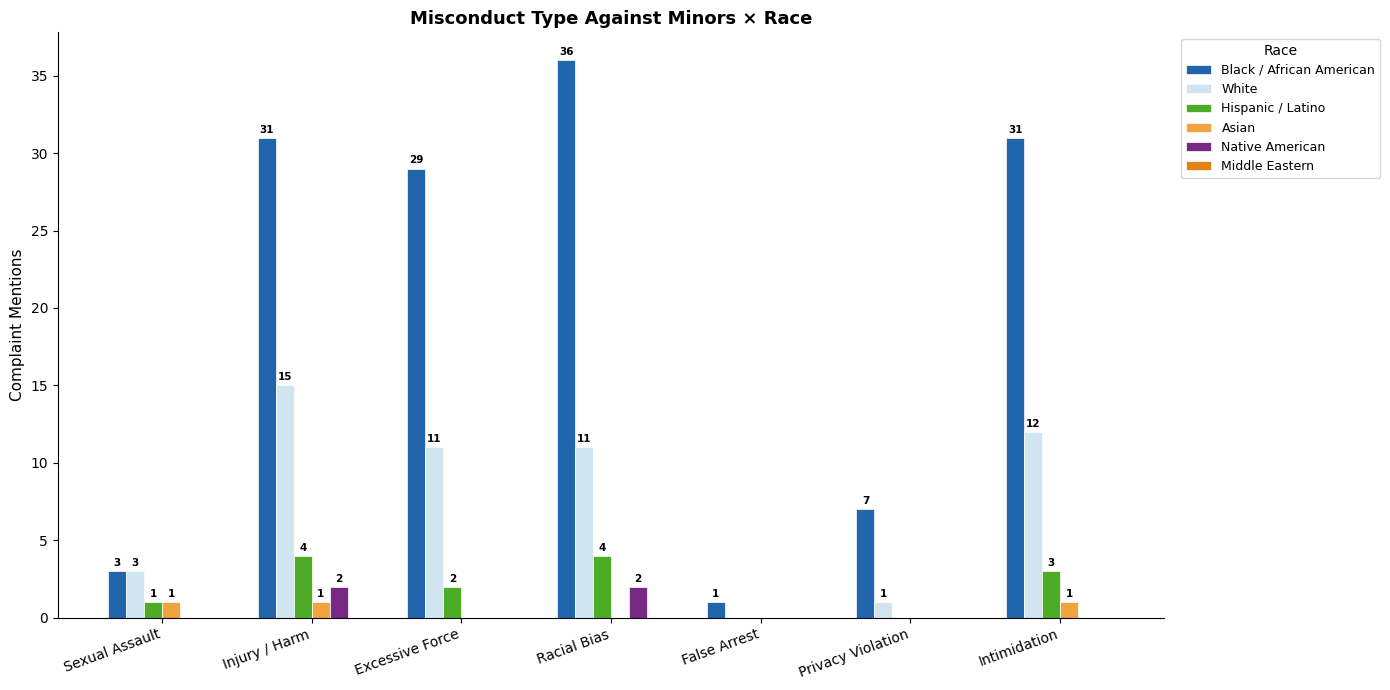

In [23]:
# ── Race × Misconduct type (grouped bar) ──────────────────────────────────────

race_order = list(race_patterns.keys())

matrix_race = pd.DataFrame(0,
    index=list(misconduct_categories.keys()),
    columns=race_order)

for i, text in enumerate(youth_narr):
    for mtype, mpat in misconduct_categories.items():
        if re.search(mpat, text, re.IGNORECASE):
            for race_label, rpat in race_patterns.items():
                if re.search(rpat, text, re.IGNORECASE):
                    matrix_race.loc[mtype, race_label] += 1

print(matrix_race)

# ── Plot ───────────────────────────────────────────────────────────────────────
race_colors = {
    'Black / African American': '#2166ac',
    'White':                    '#d1e5f0',
    'Hispanic / Latino':        '#4dac26',
    'Asian':                    '#f1a340',
    'Native American':          '#762a83',
    'Middle Eastern':           '#e08214',
}

fig, ax = plt.subplots(figsize=(14, 7))

n_misconduct = len(matrix_race)
n_races      = len(race_order)
x            = np.arange(n_misconduct)
bar_width     = 0.12
offsets       = np.linspace(-(n_races-1)/2, (n_races-1)/2, n_races) * bar_width

for i, race_label in enumerate(race_order):
    vals = matrix_race[race_label].values.astype(float)
    bars = ax.bar(
        x + offsets[i], vals,
        width=bar_width,
        color=race_colors[race_label],
        edgecolor='white', linewidth=0.5,
        label=race_label
    )
    for bar, v in zip(bars, vals):
        if v >= 1:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.2,
                    str(int(v)),
                    ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(matrix_race.index, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Complaint Mentions', fontsize=11)
ax.set_title('Misconduct Type Against Minors × Race', fontsize=13, fontweight='bold')
ax.legend(title='Race', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('misconduct_by_race.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
ax_d = fig.add_subplot(gs[1, 2])

race_misconduct = {}
all_misconduct_pat = '|'.join(misconduct_categories.values())
for label, pat in race_patterns.items():
    race_mask_local = youth_narr.str.contains(pat, case=False, regex=True)
    misc_mask_local = youth_narr.str.contains(all_misconduct_pat, case=False, regex=True)
    race_misconduct[label.split('/')[0].strip()] = (race_mask_local & misc_mask_local).sum()

rm = pd.Series(race_misconduct).sort_values()
rm = rm[rm > 0]
rm.plot(kind='barh', ax=ax_d, color='steelblue', edgecolor='k')
ax_d.set_title('Race × Any\nMisconduct', fontweight='bold')
ax_d.set_xlabel('Complaints')
for i, v in enumerate(rm):
    ax_d.text(v + 0.1, i, str(v), va='center', fontsize=8)

In [27]:
# ── Each complaint = 1 flag per category (binary, not count) ──────────────────

# one row per complaint, binary presence of each misconduct type
misconduct_flags = pd.DataFrame(index=youth_narr.index)

for mtype, pat in misconduct_categories.items():
    misconduct_flags[mtype] = youth_narr.str.contains(
        pat, case=False, regex=True).astype(int)

for race_label, rpat in race_patterns.items():
    short = race_label.split('/')[0].strip()
    misconduct_flags[f'race_{short}'] = youth_narr.str.contains(
        rpat, case=False, regex=True).astype(int)

misconduct_flags['age_bucket']    = youth_narr.apply(school_age_bucket)
misconduct_flags['any_injury']    = youth_narr.str.contains(
    '|'.join(injury_patterns.values()), case=False, regex=True).astype(int)
misconduct_flags['sexual_assault']= youth_narr.str.contains(
    '|'.join(sa_patterns.values()), case=False, regex=True).astype(int)
misconduct_flags['complaint_id']  = youth_df['COMPLAINTNUMBER'].values

# deduplicate: if same complaint number appears multiple times, keep one row
# (multiple allegations per complaint can cause row duplication)
misconduct_flags = misconduct_flags.drop_duplicates(subset='complaint_id')

print(f"Complaints before dedup: {len(youth_narr)}")
print(f"Complaints after dedup:  {len(misconduct_flags)}")
print(f"\nBinary prevalence (1 count per complaint):")
print(misconduct_flags[list(misconduct_categories.keys())].sum().sort_values(ascending=False))

Complaints before dedup: 354
Complaints after dedup:  256

Binary prevalence (1 count per complaint):
Injury / Harm        149
Intimidation         129
Excessive Force      123
Racial Bias           70
Sexual Assault        48
Privacy Violation     23
False Arrest          20
dtype: int64


In [29]:
# ── Binary co-occurrence matrix: race × misconduct ────────────────────────────
# Each cell = number of UNIQUE complaints where both appear

race_cols      = [c for c in misconduct_flags.columns if c.startswith('race_')]
misconduct_cols = list(misconduct_categories.keys())

dedup_matrix = pd.DataFrame(0,
    index=misconduct_cols,
    columns=[c.replace('race_', '') for c in race_cols])

for rc in race_cols:
    short = rc.replace('race_', '')
    for mc in misconduct_cols:
        dedup_matrix.loc[mc, short] = (
            (misconduct_flags[rc] == 1) & (misconduct_flags[mc] == 1)
        ).sum()

print(dedup_matrix)

                   Black  White  Hispanic  Asian  Native American  \
Sexual Assault         3      2         1      1                0   
Injury / Harm         21      9         4      1                1   
Excessive Force       20      7         2      0                0   
Racial Bias           26      8         4      0                1   
False Arrest           1      0         0      0                0   
Privacy Violation      4      1         0      0                0   
Intimidation          22      9         3      1                0   

                   Middle Eastern  
Sexual Assault                  0  
Injury / Harm                   0  
Excessive Force                 0  
Racial Bias                     0  
False Arrest                    0  
Privacy Violation               0  
Intimidation                    0  


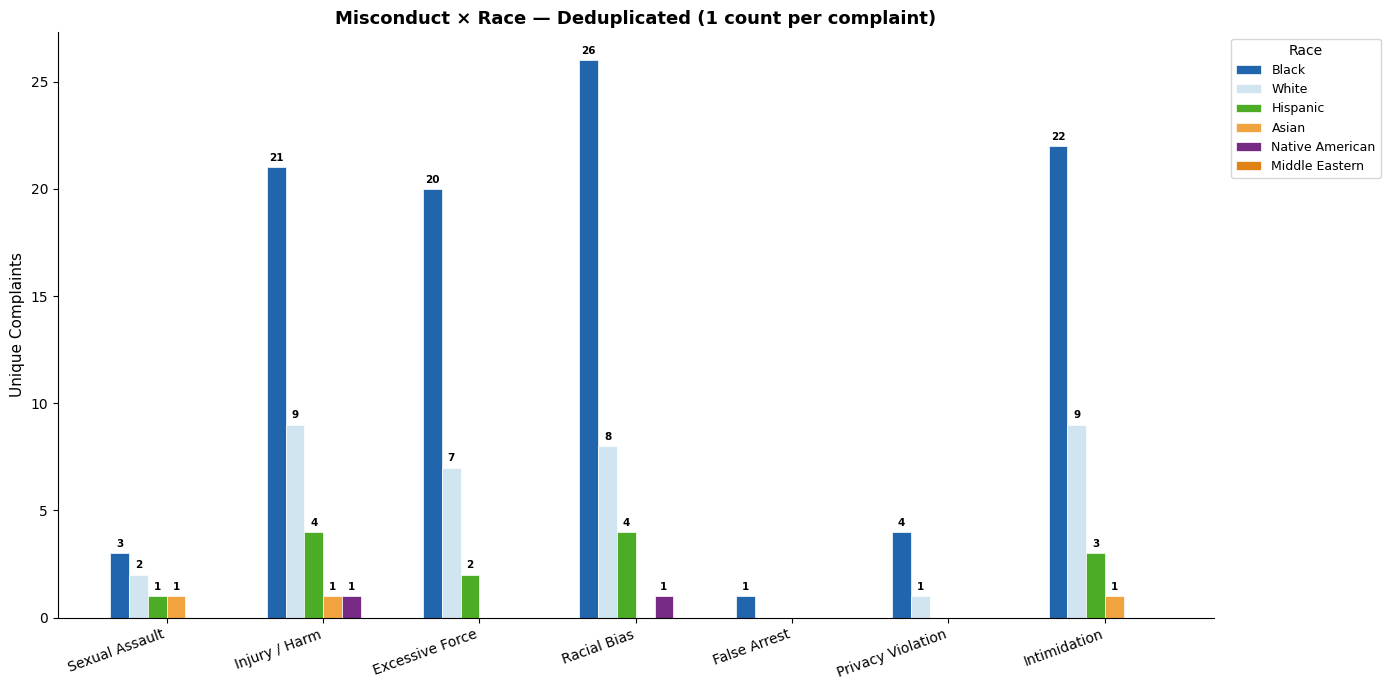

In [31]:
fig, ax = plt.subplots(figsize=(14, 7))

n_misconduct = len(dedup_matrix)
n_races      = len(dedup_matrix.columns)
x            = np.arange(n_misconduct)
bar_width    = 0.12
offsets      = np.linspace(-(n_races-1)/2, (n_races-1)/2, n_races) * bar_width

for i, race_label in enumerate(dedup_matrix.columns):
    vals = dedup_matrix[race_label].values.astype(float)
    bars = ax.bar(
        x + offsets[i], vals,
        width=bar_width,
        color=list(race_colors.values())[i],
        edgecolor='white', linewidth=0.5,
        label=race_label
    )
    for bar, v in zip(bars, vals):
        if v >= 1:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.2, str(int(v)),
                    ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(dedup_matrix.index, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Unique Complaints', fontsize=11)
ax.set_title('Misconduct × Race — Deduplicated (1 count per complaint)',
             fontsize=13, fontweight='bold')
ax.legend(title='Race', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('misconduct_race_dedup.png', dpi=150, bbox_inches='tight')
plt.show()

                   Preschool (0–4)  Elementary (5–11)  \
Sexual Assault                   2                 11   
Injury / Harm                   12                 21   
Excessive Force                 11                 15   
Racial Bias                      5                 12   
False Arrest                     2                  1   
Privacy Violation                1                  4   
Intimidation                     8                 15   

                   Middle & High School (12–17)  
Sexual Assault                                5  
Injury / Harm                                14  
Excessive Force                              13  
Racial Bias                                   6  
False Arrest                                  2  
Privacy Violation                             3  
Intimidation                                 14  


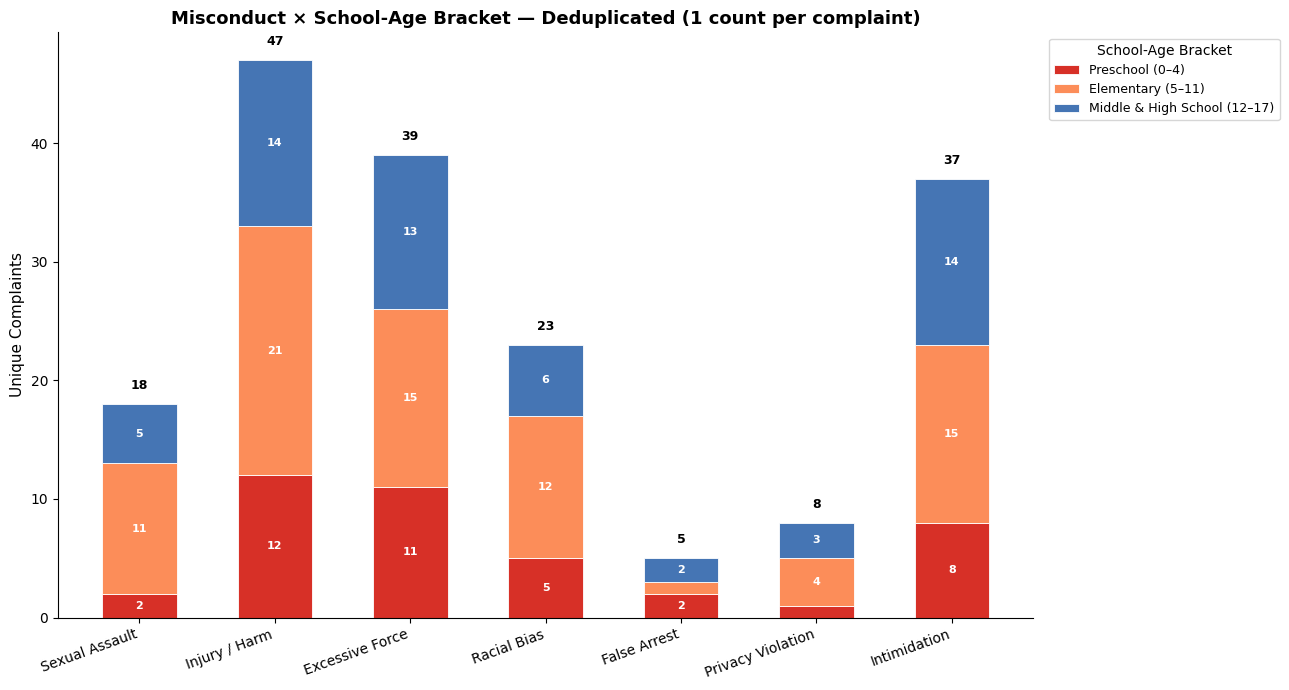

In [36]:
# ── Deduplicated School Age × Misconduct Matrix (no unknown) ──────────────────

school_order = [
    'Preschool (0–4)',
    'Elementary (5–11)',
    'Middle & High School (12–17)',
]

school_colors = {
    'Preschool (0–4)':               '#d73027',
    'Elementary (5–11)':             '#fc8d59',
    'Middle & High School (12–17)':  '#4575b4',
}

def school_age_bucket(text):
    ages = extract_ages(text)
    if not ages:
        return 'Unknown / Unspecified'
    a = min(ages)
    if a <= 4:   return 'Preschool (0–4)'
    if a <= 11:  return 'Elementary (5–11)'
    if a <= 17:  return 'Middle & High School (12–17)'
    return 'Unknown / Unspecified'

# rebuild flags with updated bucket
misconduct_flags['age_bucket'] = youth_narr.apply(school_age_bucket)

dedup_age_matrix = pd.DataFrame(0,
    index=misconduct_cols,
    columns=school_order)

for mc in misconduct_cols:
    for bracket in school_order:
        dedup_age_matrix.loc[mc, bracket] = (
            (misconduct_flags[mc] == 1) &
            (misconduct_flags['age_bucket'] == bracket)
        ).sum()

print(dedup_age_matrix)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7))
bottoms = np.zeros(len(dedup_age_matrix))

for bracket in school_order:
    vals = dedup_age_matrix[bracket].values.astype(float)
    ax.bar(dedup_age_matrix.index, vals, bottom=bottoms,
           color=school_colors[bracket], edgecolor='white',
           linewidth=0.6, label=bracket, width=0.55)
    for j, (v, b) in enumerate(zip(vals, bottoms)):
        if v >= 2:
            ax.text(j, b + v/2, str(int(v)),
                    ha='center', va='center', fontsize=8,
                    color='white', fontweight='bold')
    bottoms += vals

for j, total in enumerate(bottoms):
    ax.text(j, total + 1, str(int(total)),
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(range(len(dedup_age_matrix)))
ax.set_xticklabels(dedup_age_matrix.index, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Unique Complaints', fontsize=11)
ax.set_title('Misconduct × School-Age Bracket — Deduplicated (1 count per complaint)',
             fontsize=13, fontweight='bold')
ax.legend(title='School-Age Bracket', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('misconduct_age_dedup.png', dpi=150, bbox_inches='tight')
plt.show()

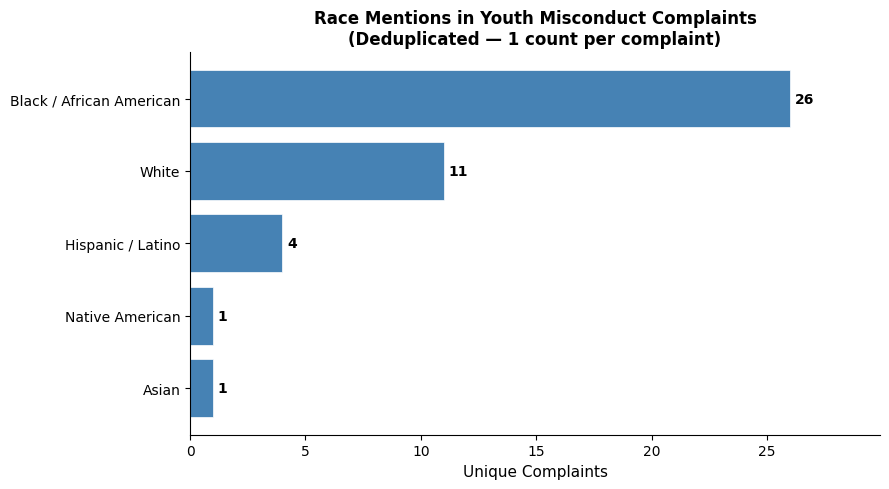

In [37]:
# ── Race mentions in youth complaints — deduplicated, simple bar ───────────────

race_dedup = {}
for race_label, rpat in race_patterns.items():
    race_dedup[race_label] = (
        misconduct_flags[f'race_{race_label.split("/")[0].strip()}'] == 1
    ).sum()

race_dedup_s = pd.Series(race_dedup).sort_values()
race_dedup_s = race_dedup_s[race_dedup_s > 0]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(race_dedup_s.index, race_dedup_s.values,
               color='steelblue', edgecolor='white', linewidth=0.5)

for bar, v in zip(bars, race_dedup_s.values):
    ax.text(v + 0.2, bar.get_y() + bar.get_height()/2,
            str(int(v)), va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Unique Complaints', fontsize=11)
ax.set_title('Race Mentions in Youth Misconduct Complaints\n(Deduplicated — 1 count per complaint)',
             fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, race_dedup_s.max() * 1.15)

plt.tight_layout()
plt.savefig('race_dedup_simple.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
fig, ax = plt.subplots(figsize=(13, 7))
bottoms = np.zeros(len(dedup_age_matrix))

for bracket in school_order:
    vals = dedup_age_matrix[bracket].values.astype(float)
    ax.bar(dedup_age_matrix.index, vals, bottom=bottoms,
           color=school_colors[bracket], edgecolor='white',
           linewidth=0.6, label=bracket, width=0.55)
    for j, (v, b) in enumerate(zip(vals, bottoms)):
        if v >= 4:
            ax.text(j, b + v/2, str(int(v)),
                    ha='center', va='center', fontsize=8,
                    color='black', fontweight='bold')
    bottoms += vals

for j, total in enumerate(bottoms):
    ax.text(j, total + 1, str(int(total)),
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(range(len(dedup_age_matrix)))
ax.set_xticklabels(dedup_age_matrix.index, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Unique Complaints', fontsize=11)
ax.set_title('Misconduct × School-Age Bracket — Deduplicated (1 count per complaint)',
             fontsize=13, fontweight='bold')
ax.legend(title='School-Age Bracket', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('misconduct_age_dedup.png', dpi=150, bbox_inches='tight')
plt.show()

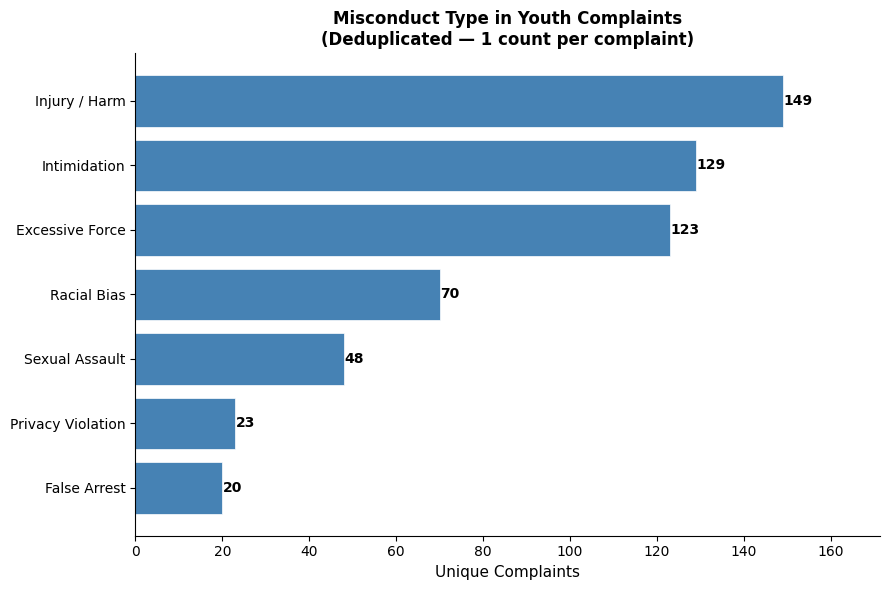

In [38]:
# ── Misconduct type prevalence — deduplicated, simple horizontal bar ───────────

misc_dedup = misconduct_flags[misconduct_cols].sum().sort_values()

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(misc_dedup.index, misc_dedup.values,
               color='steelblue', edgecolor='white', linewidth=0.5)

for bar, v in zip(bars, misc_dedup.values):
    ax.text(v + 0.2, bar.get_y() + bar.get_height()/2,
            str(int(v)), va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Unique Complaints', fontsize=11)
ax.set_title('Misconduct Type in Youth Complaints\n(Deduplicated — 1 count per complaint)',
             fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, misc_dedup.max() * 1.15)

plt.tight_layout()
plt.savefig('misconduct_simple.png', dpi=150, bbox_inches='tight')
plt.show()